In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

%%time
f_No_BCM = [[]]*Params.N_Cells_PC
f_During_BCM = [[]]*Params.N_Cells_PC
f_BCM = [[]]*Params.N_Cells_PC
f_Coupled_No_BCM = [[]]*Params.N_Cells_PC
f_Coupled_During_BCM = [[]]*Params.N_Cells_PC
f_Coupled_BCM = [[]]*Params.N_Cells_PC
cxy_No_BCM = [[]]*Params.N_Cells_PC
cxy_During_BCM = [[]]*Params.N_Cells_PC
cxy_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    f_No_BCM[ii] = [[]]*Params.N_Noise
    f_During_BCM[ii] = [[]]*Params.N_Noise
    f_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_BCM[ii] = [[]]*Params.N_Noise
    cxy_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):     
        cxy_No_BCM[ii][jj], f_No_BCM[ii][jj] = cohere(PC_No_BCM.I_Noise[ii]/nA, Noise_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_During_BCM[ii][jj], f_During_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][:len(PC_BCM.I_Noise[ii])//2]/nA, Noise_Extended_BCM.I[jj][:len(Noise_Extended_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_BCM[ii][jj], f_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_BCM.I[jj][len(Noise_Extended_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_No_BCM[ii][jj], f_Coupled_No_BCM[ii][jj] = cohere(PC_Coupled_No_BCM.I_Noise[ii]/nA, Noise_Coupled_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_During_BCM[ii][jj], f_Coupled_During_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][:len(PC_Coupled_BCM.I_Noise[ii])//2]/nA, Noise_Extended_Coupled_BCM.I[jj][:len(Noise_Extended_Coupled_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_BCM[ii][jj], f_Coupled_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][len(PC_Coupled_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_Coupled_BCM.I[jj][len(Noise_Extended_Coupled_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
    xscale('log')
    
mean_point_cxy_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    mean_point_cxy_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):
        idx_aa = []
        for kk in range(0,len(f_No_BCM[ii][jj])):
            if 10**2 <= f_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_No_BCM[ii][jj] = mean(cxy_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_During_BCM[ii][jj])):
            if 10**2 <= f_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_During_BCM[ii][jj] = mean(cxy_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_BCM[ii][jj])):
            if 10**2 <= f_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_BCM[ii][jj] = mean(cxy_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_No_BCM[ii][jj])):
            if 10**2 <= f_Coupled_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_No_BCM[ii][jj] = mean(cxy_Coupled_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_During_BCM[ii][jj])):
            if 10**2 <= f_Coupled_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_During_BCM[ii][jj] = mean(cxy_Coupled_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_BCM[ii][jj])):
            if 10**2 <= f_Coupled_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_BCM[ii][jj] = mean(cxy_Coupled_BCM[ii][jj][idx_aa])
        

UsageError: Line magic function `%%time` not found.


Text(0.5, 1.0, 'Before and after BCM firing frequencies DCN (Coupled)')

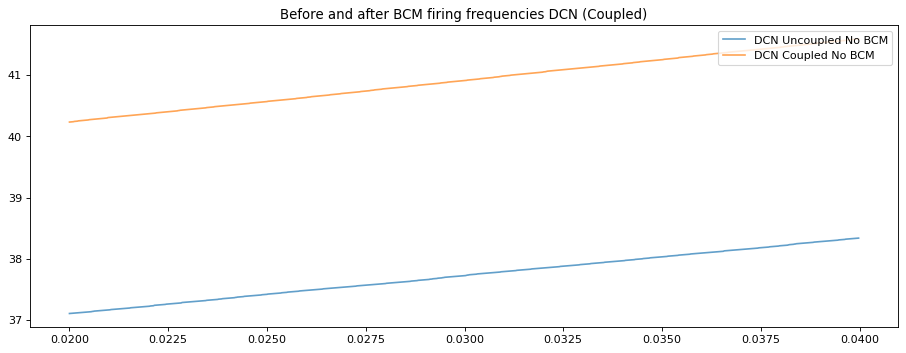

In [2]:
start = int(0.02/Params.dt)
end = int(0.04/Params.dt)
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time[start:end]/1000,DCN_No_BCM.rate[start:end], label='DCN Uncoupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time[start:end]/1000,DCN_Coupled_No_BCM.rate[start:end], label='DCN Coupled No BCM', alpha=0.7)
# plot(PC_No_BCM.rate_time,DCN_Coupled_BCM.rate[len(DCN_Coupled_BCM.rate)//2:], label='DCN Coupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies DCN (Coupled)')

(1.9000124999999999, 4.0997375, -145.06901999065113, 296.4494198036735)

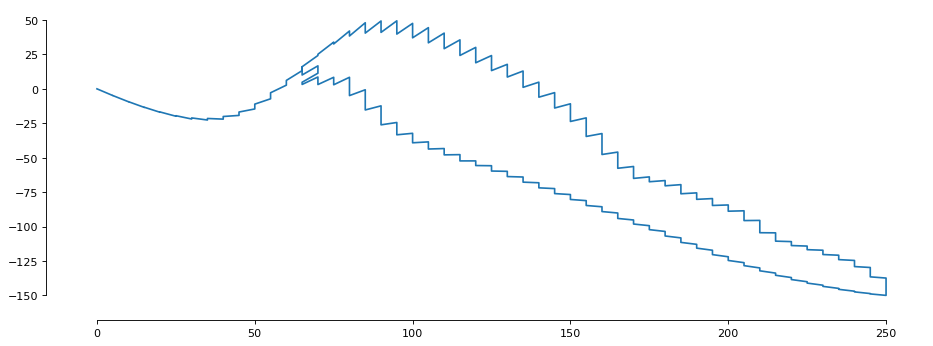

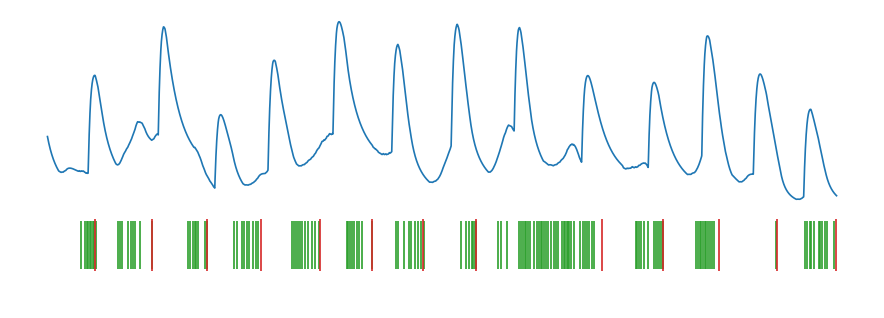

In [3]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
start = int(0/Params.dt_rec)
end = int(0.3/Params.dt_rec)
plot(mon_N_PC_BCM.rho_PC[0][start:end],mon_N_PC_BCM.phi[0][start:end])
sns.despine(offset=10, trim=True)
# plt.axis('off')

start = int(2/Params.dt_rec)
end = int(4/Params.dt_rec)
IO_spikes_aa = []
for ii in range(0,len(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]])):
    if int(start*Params.dt_rec/second) <= IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii] <= int(end*Params.dt_rec/second):
        IO_spikes_aa.append(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii])
PC_spikes_aa = []
for ii in range(0,len(PC_No_BCM.Spikemon_Cells[0])):
    if int(start*Params.dt_rec/second) <= PC_No_BCM.Spikemon_Cells[0][ii] <= int(end*Params.dt_rec/second):
        PC_spikes_aa.append(PC_No_BCM.Spikemon_Cells[0][ii])
data1 = [PC_spikes_aa,IO_spikes_aa]
colors1 = ['C{}'.format(i) for i in range(2,4)]
lineoffsets1 = np.array([-50, -50])
linelengths1 = [70, 75]
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(time_x_No_BCM[start:end]/1000,mon_N_PC_BCM.thresh_M[0][start:end])
# plot(time_x_No_BCM[start:end]/1000,PC_No_BCM.v[0][start:end]/mV)
eventplot(data1, colors=colors1, 
              lineoffsets=lineoffsets1,
              linelengths=linelengths1)
plt.axis('off')

  
  



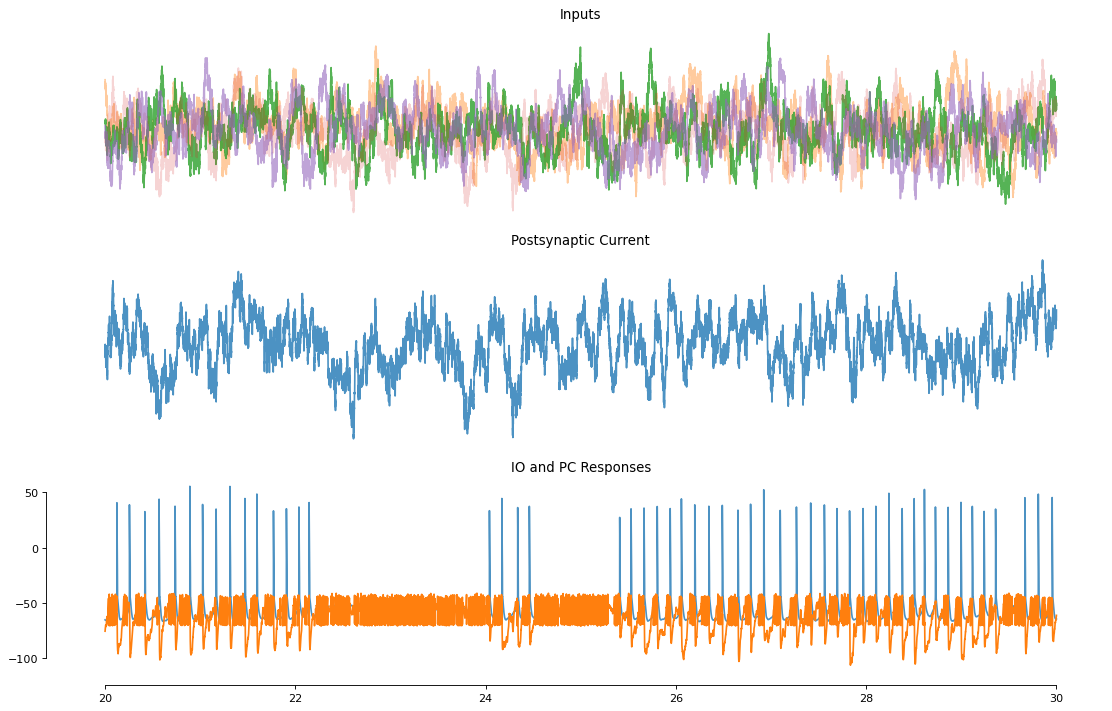

In [4]:
start = int(2/Params.dt)
end = int(3/Params.dt)
fs = 1/(Params.dt/second)  # Sampling frequency
fig, ax = plt.subplots(3, 1,figsize=(14, 3*3), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Noise):
    ax[0].plot(time_x_BCM[start:end], Noise_No_BCM.I[ii][start:end], alpha=(ii*4/10))
ax[0].set_title("Inputs")
ax[0].set_axis_off()

ax[1].plot(time_x_BCM[start:end],PC_No_BCM.I_Noise[0][start:end]/nA,alpha=0.8)
ax[1].set_title("Postsynaptic Current")
ax[1].set_axis_off()
# ax[1].set_ylim([1.2,1.8])
# ax[1].spines['right'].set_visible(False)
# ax[1].spines['top'].set_visible(False)
# ax[1].spines['bottom'].set_visible(False)


ax[2].plot(time_x_BCM[start:end]/1000,IO_No_BCM.Vs[Synapses.IO_PC_Synapse_Sources[0]][start:end]/mV, alpha=0.8)
ax[2].plot(time_x_BCM[start:end]/1000,PC_No_BCM.v[0][start:end]/mV)
ax[2].set_title("IO and PC Responses")
ax[2].spines['right'].set_visible(False)
ax[2].spines['top'].set_visible(False)
sns.despine(offset=10, trim=True)

fig.tight_layout()
plt.show()